<a href="https://colab.research.google.com/github/doannguyenminhtamcuc-ship-it/Data_VN_chapter1/blob/main/Notebook_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.3. Phân tích việc làm theo giới tính

Biểu đồ đường thể hiện xu hướng 'Tỷ lệ lao động nữ so với lao động nam ' giai đoạn 2013-2024 cho ngành kinh tế

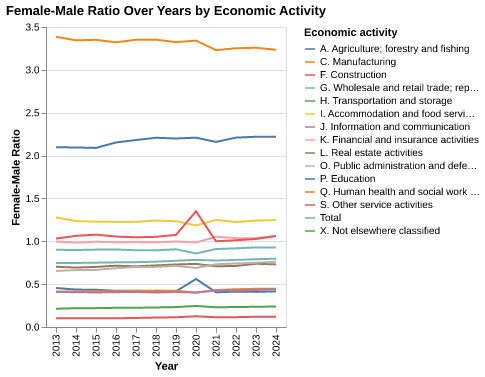

In [ ]:
import altair as alt
from IPython.display import Image, display

# Install vl-convert-python for saving charts as PNG
!pip install vl-convert-python

# Create the line chart
chart = alt.Chart(pivot_df).mark_line().encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Female-Male Ratio', title='Female-Male Ratio'),
    color='Economic activity:N',
    tooltip=['Year', 'Economic activity', 'Female-Male Ratio']
).properties(
    title='Female-Male Ratio Over Years by Economic Activity'
).interactive()

# Save chart as PNG
chart.save("chart.png")

# Display PNG image in notebook
display(Image("chart.png"))

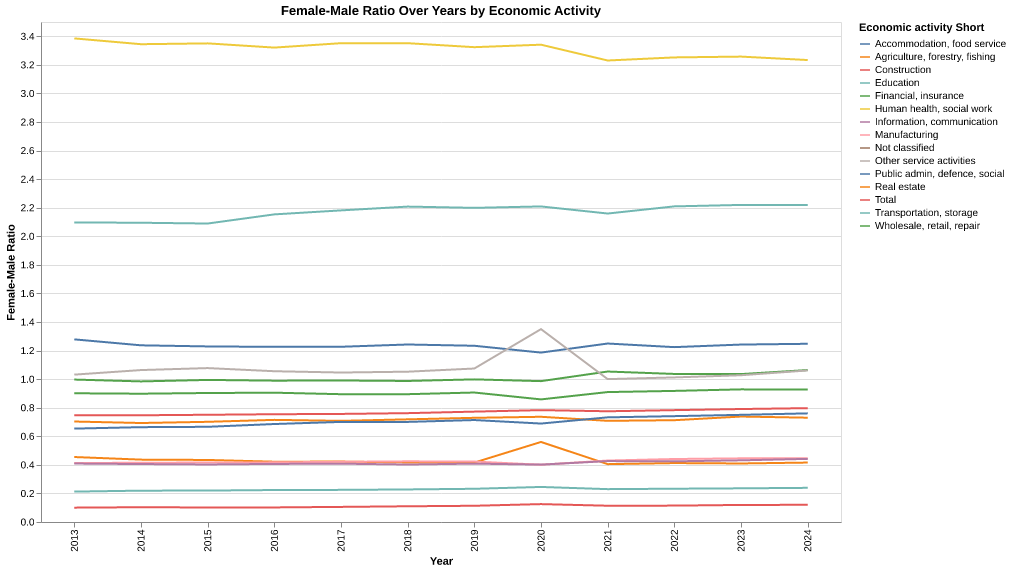

In [ ]:
!pip install vl-convert-python

import altair as alt
from IPython.display import Image, display

# Create a dictionary for mapping long names to short names
activity_short_names = {
    'A. Agriculture; forestry and fishing': 'Agriculture, forestry, fishing',
    'C. Manufacturing': 'Manufacturing',
    'F. Construction': 'Construction',
    'G. Wholesale and retail trade; repair of motor vehicles and motorcycles': 'Wholesale, retail, repair',
    'H. Transportation and storage': 'Transportation, storage',
    'I. Accommodation and food service activities': 'Accommodation, food service',
    'J. Information and communication': 'Information, communication',
    'K. Financial and insurance activities': 'Financial, insurance',
    'L. Real estate activities': 'Real estate',
    'M. Professional, scientific and technical activities': 'Professional, scientific, technical',
    'N. Administrative and support service activities': 'Administrative, support service',
    'O. Public administration and defence; compulsory social security': 'Public admin, defence, social',
    'P. Education': 'Education',
    'Q. Human health and social work activities': 'Human health, social work',
    'R. Arts, entertainment and recreation': 'Arts, entertainment, recreation',
    'S. Other service activities': 'Other service activities',
    'Total': 'Total',
    'X. Not elsewhere classified': 'Not classified'
}

# Create a new column with shortened names
pivot_df['Economic activity Short'] = pivot_df['Economic activity'].map(activity_short_names)

# Create the line chart
chart = alt.Chart(pivot_df).mark_line().encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Female-Male Ratio', title='Female-Male Ratio'),
    color='Economic activity Short:N',
    tooltip=['Year', 'Economic activity Short', 'Female-Male Ratio']
).properties(
    title='Female-Male Ratio Over Years by Economic Activity',
    width=800,
    height=500
).interactive()

# Save chart as PNG
chart.save("female_male_ratio_chart.png")

# Display image in notebook
display(Image("female_male_ratio_chart.png"))

Biểu đồ thanh thể hiện 'Tỷ lệ lao động nữ so với lao động nam' của các ngành kinh tế được sắp xếp giảm dần trong năm 2024

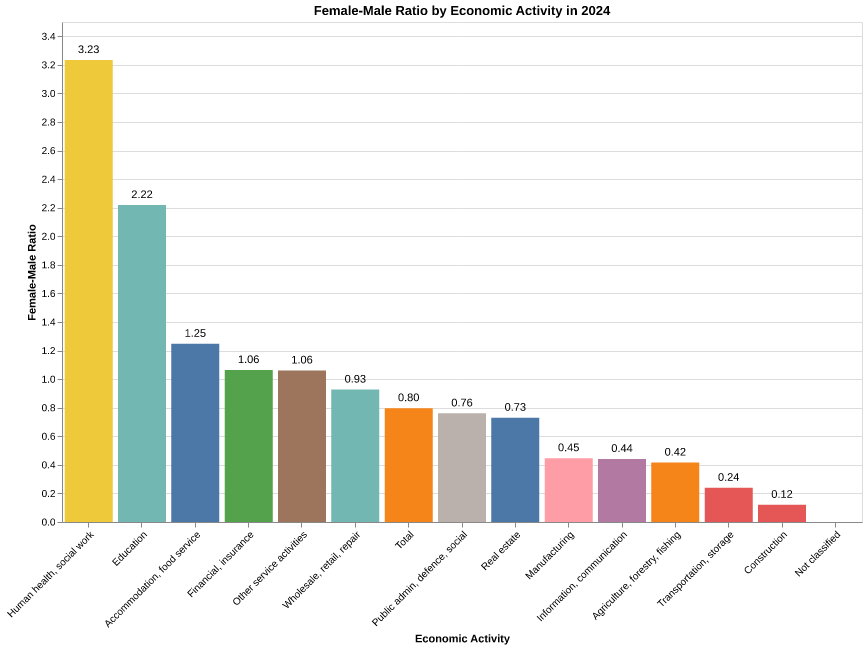

In [ ]:
!pip install vl-convert-python

import altair as alt
from IPython.display import Image, display

# Filter data for the year 2024
df_2024 = pivot_df[pivot_df['Year'] == 2024]

# Sort the dataframe by Female-Male Ratio
df_2024 = df_2024.sort_values('Female-Male Ratio', ascending=False)

# Create the bar chart
chart = alt.Chart(df_2024).mark_bar().encode(
    x=alt.X(
        'Economic activity Short',
        title='Economic Activity',
        sort='-y',
        axis=alt.Axis(labelAngle=-45)
    ),
    y=alt.Y(
        'Female-Male Ratio',
        title='Female-Male Ratio'
    ),
    tooltip=[
        'Economic activity Short',
        'Female-Male Ratio'
    ],
    color=alt.Color(
        'Economic activity Short',
        legend=None
    )
).properties(
    title='Female-Male Ratio by Economic Activity in 2024',
    width=800,
    height=500
)

# Add text labels
text = chart.mark_text(
    align='center',
    baseline='bottom',
    dy=-5
).encode(
    text=alt.Text(
        'Female-Male Ratio',
        format='.2f'
    ),
    color=alt.value('black')
)

# Combine charts
final_chart = chart + text

# Save chart as PNG
final_chart.save("female_male_ratio_2024.png")

# Display image in notebook
display(Image("female_male_ratio_2024.png"))